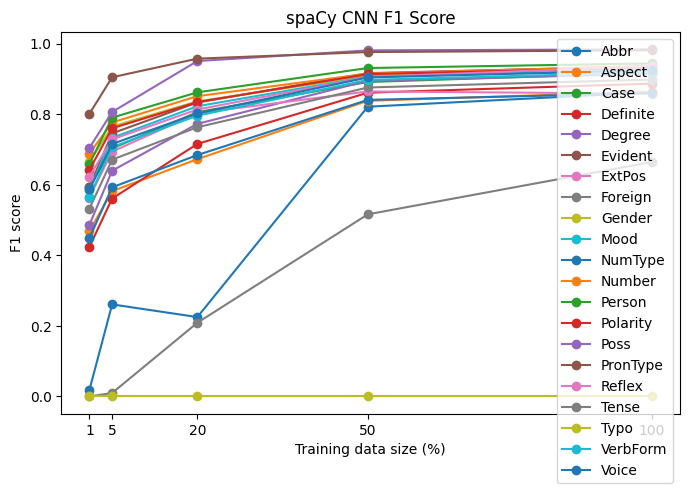

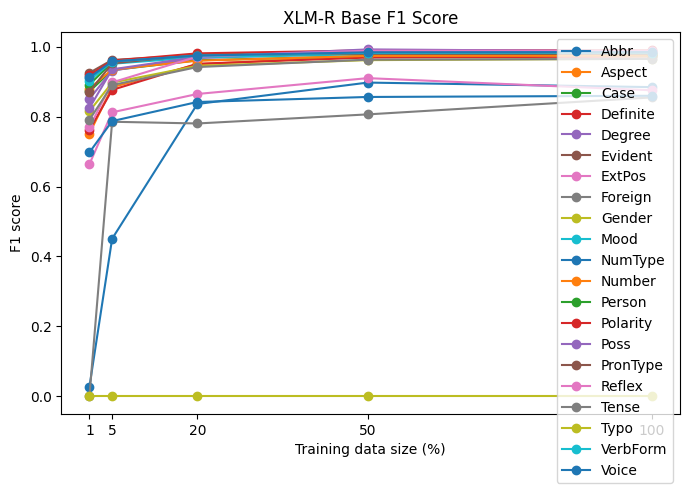

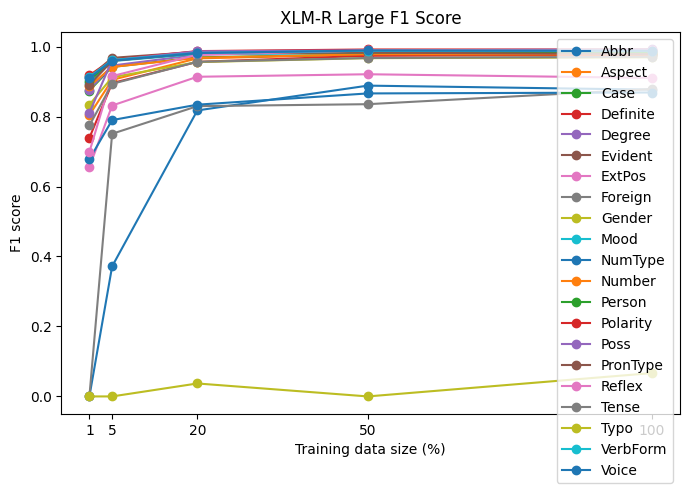

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Load CSV =====
CSV_PATH = "Summary_CSVs/evaluation_morph_per_feat.csv"
df = pd.read_csv(CSV_PATH)

# ===== 2. Extract data scale from model name =====
def extract_data_pct(model_name):
    if model_name.endswith("1pct"):
        return 1
    if model_name.endswith("5pct"):
        return 5
    if model_name.endswith("20pct"):
        return 20
    if model_name.endswith("50pct"):
        return 50
    if model_name.endswith("100pct"):
        return 100
    return None

df["data_pct"] = df["model"].apply(extract_data_pct)

# ===== 3. Define model groups =====
model_groups = {
    "spaCy CNN": df[df["model"].str.contains("spacy_cnn")],
    "XLM-R Base": df[df["model"].str.contains("xlm") & df["model"].str.contains("base")],
    "XLM-R Large": df[df["model"].str.contains("xlm") & df["model"].str.contains("large")]
}

# ===== 4. Plot learning curves =====
for title, subdf in model_groups.items():
    plt.figure(figsize=(7, 5))

    for feature, feat_df in subdf.groupby("feature"):
        feat_df = feat_df.sort_values("data_pct")
        plt.plot(
            feat_df["data_pct"],
            feat_df["f"],
            marker="o",
            label=feature
        )

    plt.xlabel("Training data size (%)")
    plt.ylabel("F1 score")
    plt.title(title + " F1 Score")
    plt.xticks([1, 5, 20, 50, 100])
    plt.legend()
    plt.tight_layout()
    plt.show()


In [2]:
# ===== Cell 1: Clean ΔF1 per model =====

def compute_delta_f1_clean(df_subset):
    """
    Compute ΔF1 = F1@100% - F1@1% for each feature
    Return DataFrame with only 'feature' and 'delta_f1'
    """
    # pivot 成 feature × data_pct，只取 F1
    pivot = df_subset.pivot(index="feature", columns="data_pct", values="f")

    # 计算 delta_f1
    pivot["delta_f1"] = pivot[100] - pivot[1]

    # 只保留 feature 和 delta_f1，feature 变成普通列
    result = pivot[["delta_f1"]].reset_index()

    return result.sort_values("delta_f1", ascending=False)

# ===== Compute ΔF1 for each model =====
delta_tables_clean = {}

for model_name, subdf in model_groups.items():
    delta_tables_clean[model_name] = compute_delta_f1_clean(subdf)
    print(f"\n=== {model_name}: ΔF1 (100% − 1%) ===")
    display(delta_tables_clean[model_name].head(21))




=== spaCy CNN: ΔF1 (100% − 1%) ===


data_pct,feature,delta_f1
0,Abbr,0.843886
7,Foreign,0.664537
3,Definite,0.463044
4,Degree,0.428244
10,NumType,0.411150
1,Aspect,0.395279
17,Tense,0.366152
19,VerbForm,0.352627
5,Evident,0.341571
9,Mood,0.339809



=== XLM-R Base: ΔF1 (100% − 1%) ===


data_pct,feature,delta_f1
0,Abbr,0.857031
7,Foreign,0.854651
1,Aspect,0.223734
16,Reflex,0.218795
6,ExtPos,0.211283
3,Definite,0.210356
17,Tense,0.174158
14,Poss,0.162169
10,NumType,0.161942
8,Gender,0.149948



=== XLM-R Large: ΔF1 (100% − 1%) ===


data_pct,feature,delta_f1
7,Foreign,0.878613
0,Abbr,0.876777
16,Reflex,0.290173
6,ExtPos,0.254932
3,Definite,0.237087
17,Tense,0.196433
10,NumType,0.190781
1,Aspect,0.183133
14,Poss,0.181059
8,Gender,0.135686


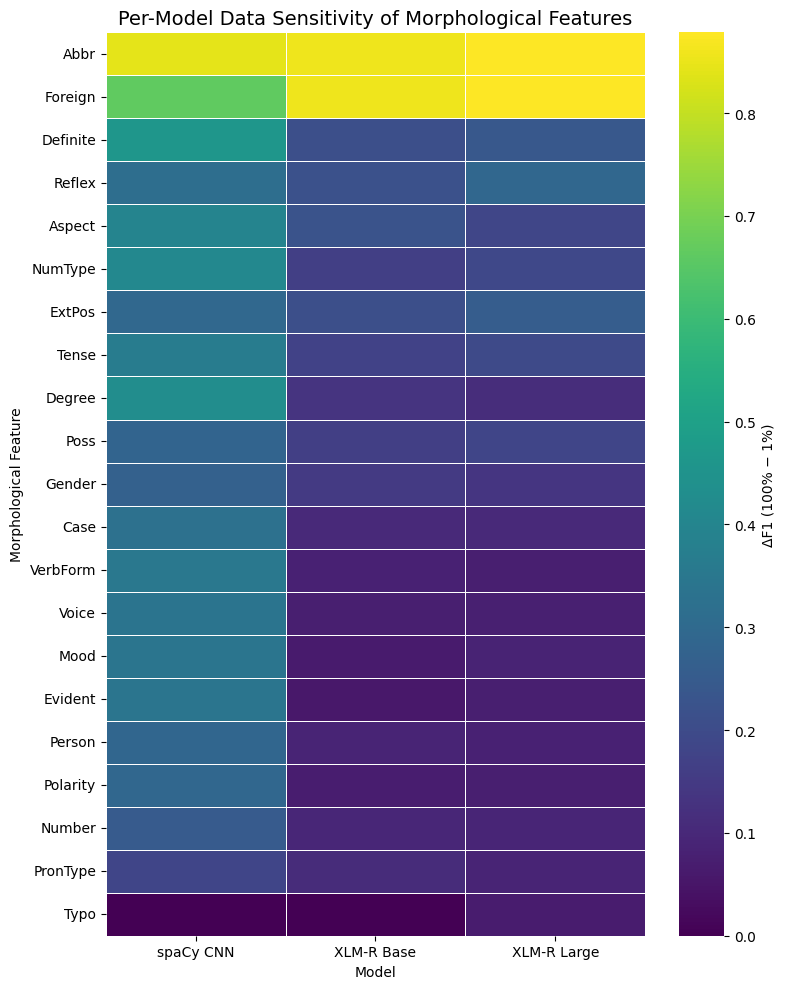

In [3]:
# ===== Cell 1b: ΔF1 Heatmap (feature × model) =====

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ 合并所有模型的 delta_f1 成一个表
heatmap_df = None

for model_name, df in delta_tables_clean.items():
    tmp = df.copy()
    tmp = tmp.rename(columns={"delta_f1": model_name})
    tmp = tmp.set_index("feature")

    if heatmap_df is None:
        heatmap_df = tmp
    else:
        heatmap_df = heatmap_df.join(tmp, how="outer")

# 2️⃣ 可选：按平均 ΔF1 排序 feature（仅用于展示顺序，不是分析指标）
heatmap_df["mean_delta"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values("mean_delta", ascending=False)
heatmap_df = heatmap_df.drop(columns="mean_delta")

# 3️⃣ 画 heatmap
plt.figure(figsize=(8, 10))

sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "ΔF1 (100% − 1%)"}
)

plt.title("Per-Model Data Sensitivity of Morphological Features", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Morphological Feature")

plt.tight_layout()
plt.show()


In [4]:
# ===== Cell 2: Cross-model aggregation (mean_1pct_f1 + mean_delta_f1) =====

# 1️⃣ 准备每个模型在 1% 和 delta_f1
cross_model_list = []

for model_name, subdf in model_groups.items():
    # pivot 出 feature × data_pct
    pivot = subdf.pivot(index="feature", columns="data_pct", values="f").reset_index()
    # 计算 delta_f1
    pivot["delta_f1"] = pivot[100] - pivot[1]
    # 保留 feature, 1% f1, delta_f1
    pivot = pivot[["feature", 1, "delta_f1"]].rename(columns={
        1: f"{model_name.replace(' ', '_')}_f1_1pct",
        "delta_f1": f"{model_name.replace(' ', '_')}_delta"
    })
    cross_model_list.append(pivot)

# 2️⃣ 合并三个模型
from functools import reduce

df_cross = reduce(lambda left, right: pd.merge(left, right, on="feature"), cross_model_list)

# 3️⃣ 计算跨模型平均
df_cross["mean_1pct_f1"] = df_cross[[col for col in df_cross.columns if "_f1_1" in col]].mean(axis=1)
df_cross["mean_delta_f1"] = df_cross[[col for col in df_cross.columns if "_delta" in col]].mean(axis=1)

# 4️⃣ 排序：可以按 mean_delta_f1 降序，或者 mean_1pct_f1 降序
df_cross = df_cross.sort_values("mean_delta_f1", ascending=False)

# 5️⃣ 显示结果
display(df_cross.head(21))


data_pct,feature,spaCy_CNN_f1_1pct,spaCy_CNN_delta,XLM-R_Base_f1_1pct,XLM-R_Base_delta,XLM-R_Large_f1_1pct,XLM-R_Large_delta,mean_1pct_f1,mean_delta_f1
0,Abbr,0.018100,0.843886,0.027027,0.857031,0.000000,0.876777,0.015042,0.859231
7,Foreign,0.000000,0.664537,0.000000,0.854651,0.000000,0.878613,0.000000,0.799267
3,Definite,0.423544,0.463044,0.761257,0.210356,0.739130,0.237087,0.641310,0.303496
16,Reflex,0.623296,0.313358,0.768859,0.218795,0.699051,0.290173,0.697069,0.274109
1,Aspect,0.468721,0.395279,0.751024,0.223734,0.804348,0.183133,0.674697,0.267382
10,NumType,0.448617,0.411150,0.697380,0.161942,0.677906,0.190781,0.607968,0.254624
6,ExtPos,0.563636,0.294573,0.663717,0.211283,0.655462,0.254932,0.627605,0.253596
17,Tense,0.532060,0.366152,0.790535,0.174158,0.774415,0.196433,0.699003,0.245581
4,Degree,0.486151,0.428244,0.850471,0.131494,0.876490,0.111098,0.737704,0.223612
14,Poss,0.704319,0.279288,0.824207,0.162169,0.810811,0.181059,0.779779,0.207505


In [5]:
# ===== Cell 3: Single-model High-Stability features (Updated) =====

top_k = 10  # 可以改成 top-k 或 top-percentile

high_stability_tables = {}

for model_name, subdf in model_groups.items():
    # 1️⃣ pivot 出 feature × data_pct
    pivot = subdf.pivot(index="feature", columns="data_pct", values="f").reset_index()
    pivot["delta_f1"] = pivot[100] - pivot[1]
    pivot["f1_1pct"] = pivot[1]
    pivot["f1_100pct"] = pivot[100]

    # 2️⃣ 先按 1% F1 降序排序
    pivot_sorted = pivot.sort_values("f1_1pct", ascending=False)

    # 3️⃣ 取 top-k，再按 delta_f1 升序
    top_features = pivot_sorted.head(top_k).sort_values("delta_f1", ascending=True)

    # 4️⃣ 保留需要列
    top_features_display = top_features[["feature", "f1_1pct", "f1_100pct", "delta_f1"]]

    high_stability_tables[model_name] = top_features_display

    print(f"\n=== {model_name}: High-Stability Features (Top {top_k}) ===")
    display(top_features_display)



=== spaCy CNN: High-Stability Features (Top 10) ===


data_pct,feature,f1_1pct,f1_100pct,delta_f1
15,PronType,0.800943,0.981195,0.180252
11,Number,0.688470,0.936606,0.248136
8,Gender,0.664421,0.933055,0.268634
14,Poss,0.704319,0.983607,0.279288
12,Person,0.658812,0.943903,0.285091
13,Polarity,0.642088,0.932430,0.290342
16,Reflex,0.623296,0.936654,0.313358
2,Case,0.592863,0.917385,0.324521
20,Voice,0.586710,0.924393,0.337683
5,Evident,0.594243,0.935814,0.341571



=== XLM-R Base: High-Stability Features (Top 10) ===


data_pct,feature,f1_1pct,f1_100pct,delta_f1
5,Evident,0.924911,0.981499,0.056588
9,Mood,0.910638,0.973723,0.063084
13,Polarity,0.917927,0.988919,0.070993
20,Voice,0.911832,0.984379,0.072547
19,VerbForm,0.902856,0.982687,0.079831
12,Person,0.891039,0.978544,0.087505
11,Number,0.879801,0.973741,0.093940
2,Case,0.871613,0.973967,0.102354
15,PronType,0.870829,0.979216,0.108388
4,Degree,0.850471,0.981965,0.131494



=== XLM-R Large: High-Stability Features (Top 10) ===


data_pct,feature,f1_1pct,f1_100pct,delta_f1
5,Evident,0.912263,0.985055,0.072792
13,Polarity,0.918006,0.991558,0.073551
19,VerbForm,0.913762,0.987619,0.073856
20,Voice,0.910238,0.987917,0.077679
12,Person,0.902289,0.982136,0.079847
9,Mood,0.896040,0.979567,0.083527
15,PronType,0.890083,0.978325,0.088241
11,Number,0.886745,0.977535,0.090790
2,Case,0.874208,0.976694,0.102486
4,Degree,0.876490,0.987588,0.111098


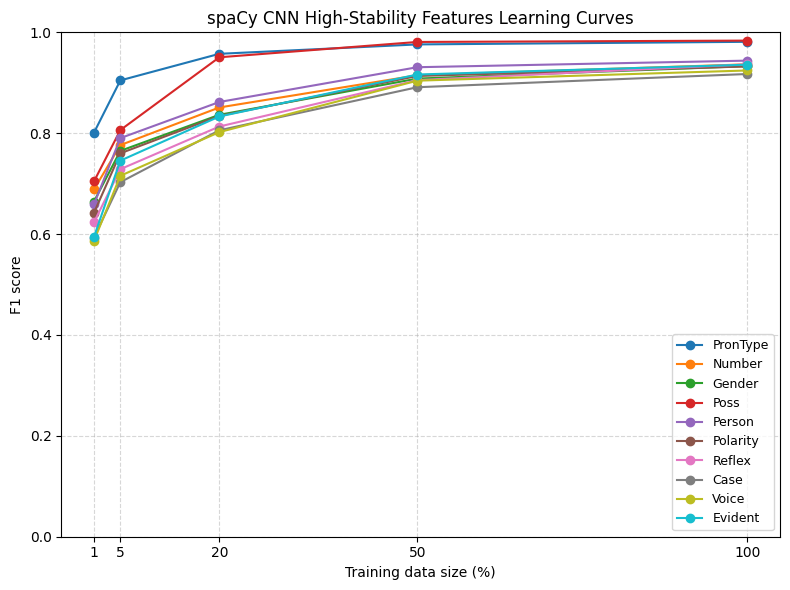

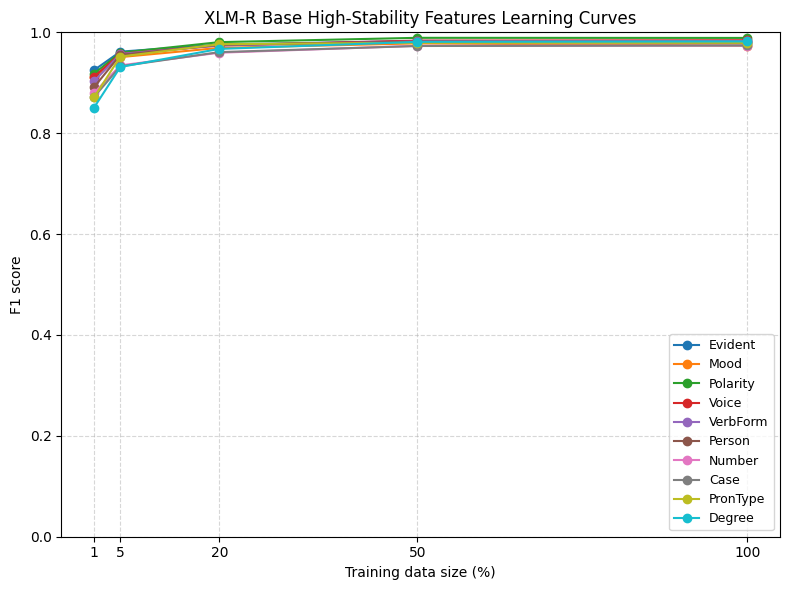

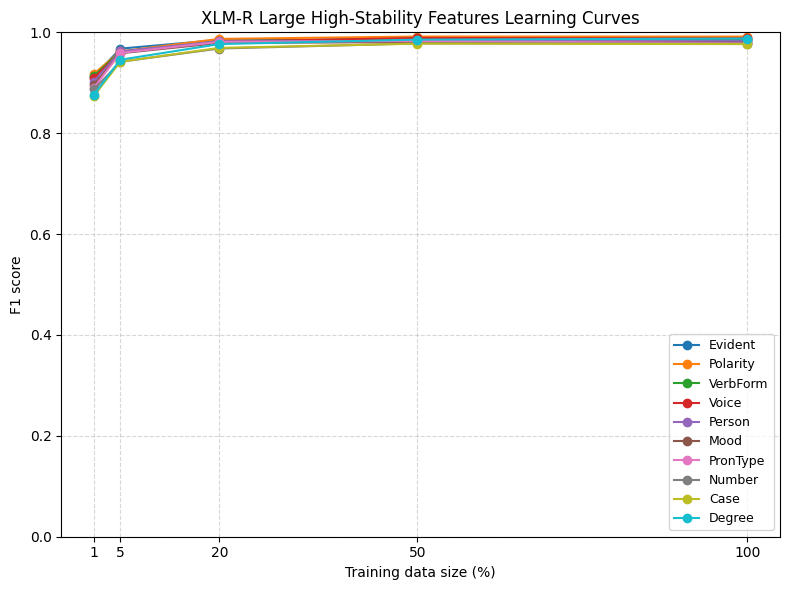

In [6]:
# ===== Cell 3b: Visualize High-Stability Features =====

plt.rcParams.update({'figure.figsize': (8,6)})

for model_name, features_df in high_stability_tables.items():
    subdf = model_groups[model_name]

    plt.figure()
    
    # 遍历每个 high-stability feature
    for feature in features_df["feature"]:
        feat_df = subdf[subdf["feature"] == feature].sort_values("data_pct")
        plt.plot(
            feat_df["data_pct"],
            feat_df["f"],
            marker="o",
            label=feature
        )
    
    plt.xlabel("Training data size (%)")
    plt.ylabel("F1 score")
    plt.title(f"{model_name} High-Stability Features Learning Curves")
    plt.xticks([1, 5, 20, 50, 100])
    plt.ylim(0, 1)  # F1 score 范围 0-1
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [7]:
# ===== Cell 4: Cross-Model High-Stability Features (with per-model 1% F1) =====

# 1️⃣ 排序：先按 mean_1pct_f1 降序
df_cross_sorted = df_cross.sort_values("mean_1pct_f1", ascending=False)

# 2️⃣ 筛选 top-n 的 mean_1pct_f1
top_n = 10
top_features = df_cross_sorted.head(top_n)

# 3️⃣ 在 top_features 中，再按 mean_delta_f1 升序（低 → 高）
cross_high_stability = top_features.sort_values("mean_delta_f1", ascending=True)

# 4️⃣ 保留必要列：feature + mean + 各模型 1% F1 + mean_delta_f1
cols_to_keep = ["feature",
                "spaCy_CNN_f1_1pct",
                "XLM-R_Base_f1_1pct",
                "XLM-R_Large_f1_1pct",
                "mean_1pct_f1",
                "mean_delta_f1"]

cross_high_stability = cross_high_stability[cols_to_keep]

# 5️⃣ 显示结果
print("===== Cross-Model High-Stability Features (with per-model 1pct F1) ====")
display(cross_high_stability)


===== Cross-Model High-Stability Features (with per-model 1pct F1) ====


data_pct,feature,spaCy_CNN_f1_1pct,XLM-R_Base_f1_1pct,XLM-R_Large_f1_1pct,mean_1pct_f1,mean_delta_f1
15,PronType,0.800943,0.870829,0.890083,0.853952,0.125627
11,Number,0.688470,0.879801,0.886745,0.818338,0.144289
13,Polarity,0.642088,0.917927,0.918006,0.826007,0.144962
12,Person,0.658812,0.891039,0.902289,0.817380,0.150814
5,Evident,0.594243,0.924911,0.912263,0.810472,0.156984
9,Mood,0.586190,0.910638,0.896040,0.797623,0.162140
20,Voice,0.586710,0.911832,0.910238,0.802927,0.162636
19,VerbForm,0.565812,0.902856,0.913762,0.794144,0.168771
2,Case,0.592863,0.871613,0.874208,0.779561,0.176454
14,Poss,0.704319,0.824207,0.810811,0.779779,0.207505


In [8]:
## ===== Cell 5: Single-Model Data-Sensitive Features (Updated & Sorted) =====

# 函数：计算单模型 data-sensitive features
def single_model_data_sensitive(df_subset, top_n=10):
    """
    筛选 data-sensitive features:
    1% F1 低 + ΔF1 高
    逻辑：
    1️⃣ 先按 delta_f1 降序选候选（top 2*top_n）
    2️⃣ 在候选中按 f1_1pct 升序（低 → 高）
    3️⃣ 输出最终表格按 delta_f1 降序排列（最 data-sensitive 在上）
    """
    # pivot 出 feature × data_pct
    pivot = df_subset.pivot(index="feature", columns="data_pct", values="f").reset_index()
    pivot["delta_f1"] = pivot[100] - pivot[1]
    pivot["f1_1pct"] = pivot[1]
    pivot["f1_100pct"] = pivot[100]
    
    # 1️⃣ 先按 delta_f1 降序（高 → 低），取 top 2*top_n 作为候选
    top_delta = pivot.sort_values("delta_f1", ascending=False).head(top_n*2)
    
    # 2️⃣ 在候选中按 f1_1pct 升序（低 → 高），取 top_n
    data_sensitive_features = top_delta.sort_values("f1_1pct", ascending=True).head(top_n)
    
    # 3️⃣ 最终按 delta_f1 降序排列，最 data-sensitive 在上
    data_sensitive_features = data_sensitive_features.sort_values("delta_f1", ascending=False)
    
    # 保留必要列
    return data_sensitive_features[["feature", "f1_1pct", "f1_100pct", "delta_f1"]]

# 对每个模型应用
for model_name, subdf in model_groups.items():
    print(f"\n=== {model_name}: Data-Sensitive Features ===")
    display(single_model_data_sensitive(subdf, top_n=10))



=== spaCy CNN: Data-Sensitive Features ===


data_pct,feature,f1_1pct,f1_100pct,delta_f1
0,Abbr,0.018100,0.861985,0.843886
7,Foreign,0.000000,0.664537,0.664537
3,Definite,0.423544,0.886588,0.463044
4,Degree,0.486151,0.914395,0.428244
10,NumType,0.448617,0.859766,0.411150
1,Aspect,0.468721,0.864000,0.395279
17,Tense,0.532060,0.898212,0.366152
19,VerbForm,0.565812,0.918439,0.352627
9,Mood,0.586190,0.925999,0.339809
6,ExtPos,0.563636,0.858209,0.294573



=== XLM-R Base: Data-Sensitive Features ===


data_pct,feature,f1_1pct,f1_100pct,delta_f1
0,Abbr,0.027027,0.884058,0.857031
7,Foreign,0.000000,0.854651,0.854651
1,Aspect,0.751024,0.974757,0.223734
16,Reflex,0.768859,0.987654,0.218795
6,ExtPos,0.663717,0.875000,0.211283
3,Definite,0.761257,0.971613,0.210356
17,Tense,0.790535,0.964692,0.174158
14,Poss,0.824207,0.986376,0.162169
10,NumType,0.697380,0.859322,0.161942
8,Gender,0.815278,0.965226,0.149948



=== XLM-R Large: Data-Sensitive Features ===


data_pct,feature,f1_1pct,f1_100pct,delta_f1
7,Foreign,0.000000,0.878613,0.878613
0,Abbr,0.000000,0.876777,0.876777
16,Reflex,0.699051,0.989224,0.290173
6,ExtPos,0.655462,0.910394,0.254932
3,Definite,0.739130,0.976217,0.237087
17,Tense,0.774415,0.970847,0.196433
10,NumType,0.677906,0.868687,0.190781
1,Aspect,0.804348,0.987480,0.183133
14,Poss,0.810811,0.991870,0.181059
8,Gender,0.833672,0.969358,0.135686



=== spaCy CNN: Data-Sensitive Features Learning Curves ===


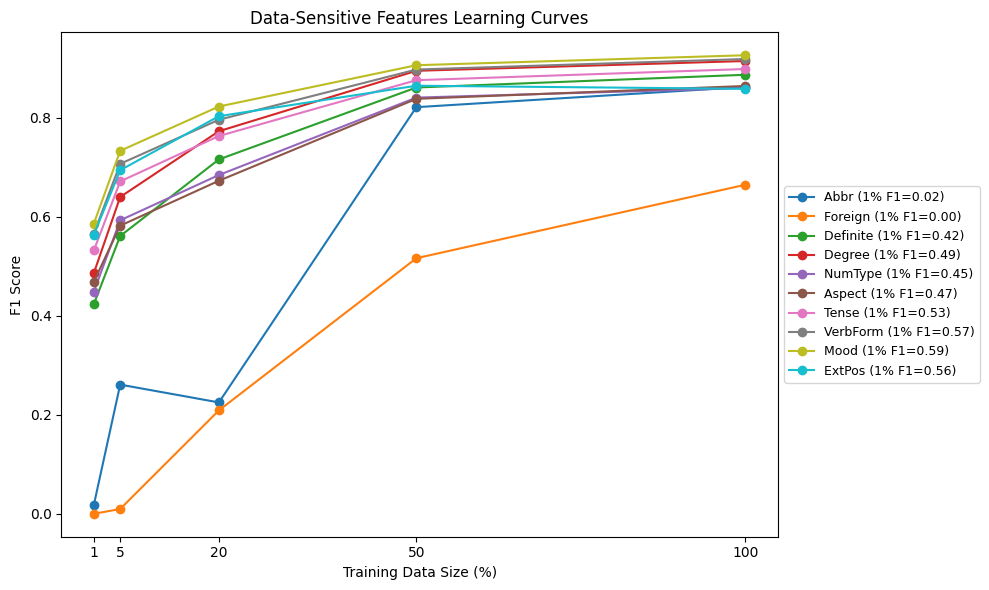


=== XLM-R Base: Data-Sensitive Features Learning Curves ===


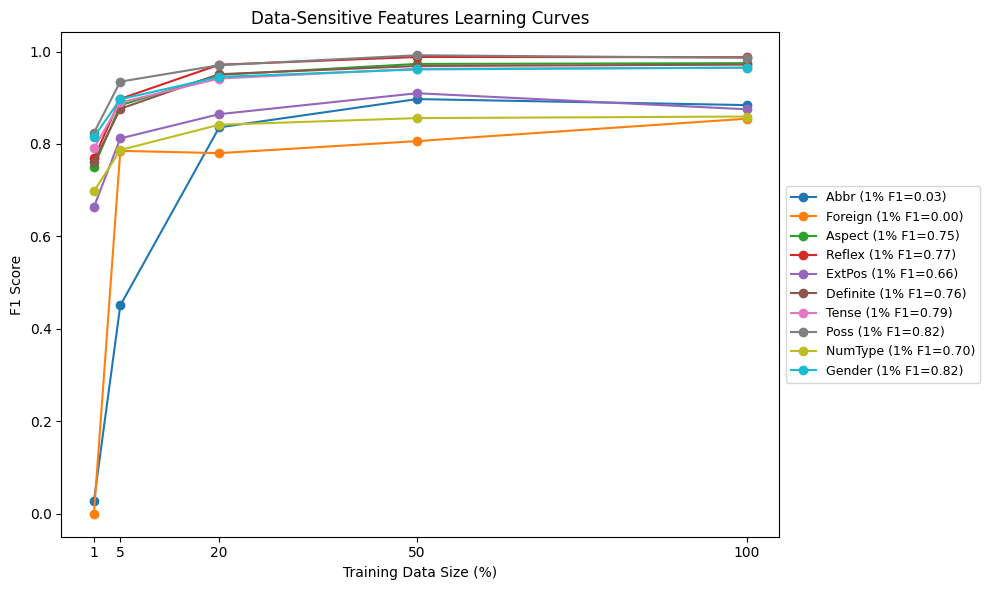


=== XLM-R Large: Data-Sensitive Features Learning Curves ===


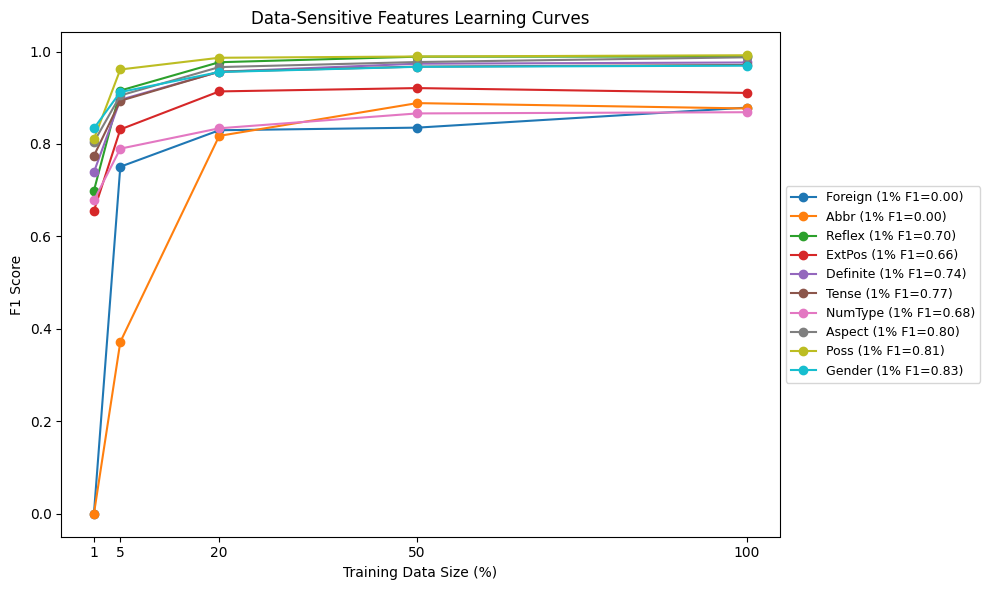

In [9]:
## ===== Cell 5b: Visualize Single-Model Data-Sensitive Features =====

import matplotlib.pyplot as plt

# 函数：绘制学习曲线
def plot_data_sensitive_features(df_subset, top_n=10):
    """
    可视化单模型 data-sensitive features 的学习曲线
    """
    # 先选出 top data-sensitive features
    top_features = single_model_data_sensitive(df_subset, top_n=top_n)
    feature_list = top_features["feature"].tolist()
    
    plt.figure(figsize=(10, 6))
    
    for feature in feature_list:
        feat_df = df_subset[df_subset["feature"] == feature].sort_values("data_pct")
        plt.plot(
            feat_df["data_pct"],
            feat_df["f"],
            marker="o",
            label=f"{feature} (1% F1={feat_df[feat_df['data_pct']==1]['f'].values[0]:.2f})"
        )
    
    plt.xlabel("Training Data Size (%)")
    plt.ylabel("F1 Score")
    plt.title("Data-Sensitive Features Learning Curves")
    plt.xticks([1, 5, 20, 50, 100])
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
    plt.tight_layout()
    plt.show()

# 对每个模型绘制
for model_name, subdf in model_groups.items():
    print(f"\n=== {model_name}: Data-Sensitive Features Learning Curves ===")
    plot_data_sensitive_features(subdf, top_n=10)


In [10]:
## ===== Cell 6: Cross-Model Data-Sensitive Features (with 1% F1 scores & Sorted) =====

def cross_model_data_sensitive(df_cross, top_n=10):
    """
    筛选跨模型 Data-Sensitive features：
    逻辑：
    1️⃣ 先按 mean_delta_f1 降序选候选（top 2*top_n）
    2️⃣ 在候选中按 mean_1pct_f1 升序（低 → 高）
    3️⃣ 输出 top_n，并按 mean_delta_f1 降序排列
    """
    # 1️⃣ 按 mean_delta_f1 降序
    df_sorted = df_cross.sort_values("mean_delta_f1", ascending=False)
    
    # 2️⃣ 取 top 2*top_n ΔF1 高的部分
    df_top_delta = df_sorted.head(top_n*2)
    
    # 3️⃣ 在候选中按 mean_1pct_f1 升序（低 → 高），取 top_n
    df_final = df_top_delta.sort_values("mean_1pct_f1", ascending=True).head(top_n)
    
    # 4️⃣ 最终按 mean_delta_f1 降序排列
    df_final = df_final.sort_values("mean_delta_f1", ascending=False)
    
    return df_final

# 筛选 top 10 跨模型 Data-Sensitive features
cross_data_sensitive = cross_model_data_sensitive(df_cross, top_n=10)

# 显示列：feature + 3个模型 1% F1 + mean指标
display_cols = [
    "feature",
    "spaCy_CNN_f1_1pct",
    "XLM-R_Base_f1_1pct",
    "XLM-R_Large_f1_1pct",
    "mean_1pct_f1",
    "mean_delta_f1"
]

print("===== Cross-Model Data-Sensitive Features (with per-model 1pct F1) ====")
display(cross_data_sensitive[display_cols])


===== Cross-Model Data-Sensitive Features (with per-model 1pct F1) ====


data_pct,feature,spaCy_CNN_f1_1pct,XLM-R_Base_f1_1pct,XLM-R_Large_f1_1pct,mean_1pct_f1,mean_delta_f1
0,Abbr,0.018100,0.027027,0.000000,0.015042,0.859231
7,Foreign,0.000000,0.000000,0.000000,0.000000,0.799267
3,Definite,0.423544,0.761257,0.739130,0.641310,0.303496
16,Reflex,0.623296,0.768859,0.699051,0.697069,0.274109
1,Aspect,0.468721,0.751024,0.804348,0.674697,0.267382
10,NumType,0.448617,0.697380,0.677906,0.607968,0.254624
6,ExtPos,0.563636,0.663717,0.655462,0.627605,0.253596
17,Tense,0.532060,0.790535,0.774415,0.699003,0.245581
4,Degree,0.486151,0.850471,0.876490,0.737704,0.223612
8,Gender,0.664421,0.815278,0.833672,0.771124,0.184756
